# Detection d'objets dans des images satellites et aeriennes - DOTA-v1.0

Ce notebook correspond au projet individuel sur la detection d'objets, l'apprentissage profond et l'inference causale.

Le dataset utilise est **DOTA-v1.0** (*Dataset for Object Detection in Aerial Images*).  
Page officielle : https://captain-whu.github.io/DOTA/

Date de telechargement / organisation locale des donnees : **2026-05-26**.  
Cette date peut etre corrigee si necessaire.

Dans cette premiere partie, on ne cherche pas encore a entrainer un modele. L'objectif est d'abord de comprendre les donnees : images, annotations, classes, boites orientees et indicateur de difficulte.

## 1. Exploration du jeu de donnees

Avant d'utiliser un modele de deep learning, il faut comprendre ce que contient le dataset.

Pour DOTA, chaque objet est annote avec une **boite orientee** : au lieu d'avoir seulement `(xmin, ymin, xmax, ymax)`, on a 8 coordonnees correspondant aux 4 coins du polygone :

`x1 y1 x2 y2 x3 y3 x4 y4 classe difficult`

L'indicateur `difficult` vaut generalement :

- `0` : objet normal ;
- `1` : objet difficile a annoter ou a detecter.

Les deux premieres lignes d'un fichier d'annotation contiennent souvent des metadonnees comme la source de l'image et la resolution au sol (`gsd`).

In [98]:
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 5)

In [99]:
# Les chemins sont relatifs au dossier du projet pour que le notebook reste portable.
PROJECT_DIR = Path.cwd()

TRAIN_IMG_DIR = PROJECT_DIR / "Training Data" / "Images"
TRAIN_LABEL_DIR = PROJECT_DIR / "Training Data" / "LabelTxt"

VAL_IMG_DIR = PROJECT_DIR / "Validation Data" / "Images"
VAL_LABEL_DIR = PROJECT_DIR / "Validation Data" / "LabelTxt"

TEST_IMG_DIR = PROJECT_DIR / "Testing Images" / "Images"

paths = {
    "Images train": TRAIN_IMG_DIR,
    "Annotations train": TRAIN_LABEL_DIR,
    "Images validation": VAL_IMG_DIR,
    "Annotations validation": VAL_LABEL_DIR,
    "Images test": TEST_IMG_DIR,
}

for name, path in paths.items():
    print(f"{name:22s} | existe: {path.exists()} | {path}")

Images train           | existe: True | c:\Users\Tazi\Desktop\School\Projet\dota-minimap-object-detection\Training Data\Images
Annotations train      | existe: True | c:\Users\Tazi\Desktop\School\Projet\dota-minimap-object-detection\Training Data\LabelTxt
Images validation      | existe: True | c:\Users\Tazi\Desktop\School\Projet\dota-minimap-object-detection\Validation Data\Images
Annotations validation | existe: True | c:\Users\Tazi\Desktop\School\Projet\dota-minimap-object-detection\Validation Data\LabelTxt
Images test            | existe: True | c:\Users\Tazi\Desktop\School\Projet\dota-minimap-object-detection\Testing Images\Images


In [100]:
# Comptage simple des fichiers disponibles.
def count_files(folder, pattern):
    return len(list(folder.glob(pattern))) if folder.exists() else 0

summary_files = pd.DataFrame(
    [
        {"ensemble": "train", "images": count_files(TRAIN_IMG_DIR, "*.png"), "annotations": count_files(TRAIN_LABEL_DIR, "*.txt")},
        {"ensemble": "validation", "images": count_files(VAL_IMG_DIR, "*.png"), "annotations": count_files(VAL_LABEL_DIR, "*.txt")},
        {"ensemble": "test", "images": count_files(TEST_IMG_DIR, "*.png"), "annotations": 0},
    ]
)

summary_files

,ensemble,images,annotations
0,train,1411,1411
1,validation,458,458
2,test,937,0


### Lecture d'un premier fichier d'annotation

On commence par afficher quelques lignes d'un fichier `.txt`. Cela permet de verifier le format reel avant d'ecrire une fonction de chargement.

In [101]:
first_label_file = sorted(TRAIN_LABEL_DIR.glob("*.txt"))[0]
print(first_label_file.name)

with open(first_label_file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i >= 11:
            break

P0000.txt
imagesource:GoogleEarth
gsd:0.146343590398
2753 2408 2861 2385 2888 2468 2805 2502 plane 0
3445 3391 3484 3409 3478 3422 3437 3402 large-vehicle 0
3185 4158 3195 4161 3175 4204 3164 4199 large-vehicle 0
2870 4250 2916 4268 2912 4283 2866 4263 large-vehicle 0
630 1674 628 1666 640 1654 644 1666 small-vehicle 0
636 1713 633 1706 646 1698 650 1706 small-vehicle 0
717 76 726 78 722 95 714 90 small-vehicle 0
737 82 744 84 739 101 731 98 small-vehicle 0
658 242 648 237 657 222 667 225 small-vehicle 1
735 122 754 129 750 136 733 128 small-vehicle 0


### Fonction de lecture des annotations DOTA

La fonction suivante transforme les fichiers texte de DOTA en tableau `pandas`.  
Chaque ligne du tableau correspond a un objet annote.

On garde pour l'instant les coordonnees orientees brutes, car elles sont importantes pour comprendre le dataset et pour decider plus tard si on travaille avec un modele OBB ou avec des boites horizontales.

In [102]:
def parse_dota_label_file(label_path, split):
    """Lit un fichier d'annotation DOTA et retourne les objets sous forme de dictionnaires."""
    rows = []
    image_id = label_path.stem
    image_source = None
    gsd = None

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if line.startswith("imagesource:"):
                image_source = line.split(":", 1)[1]
                continue

            if line.startswith("gsd:"):
                value = line.split(":", 1)[1]
                gsd = np.nan if value == "null" else float(value)
                continue

            parts = line.split()
            if len(parts) < 10:
                continue

            coords = [float(x) for x in parts[:8]]
            class_name = parts[8]
            difficult = int(parts[9])

            xs = coords[0::2]
            ys = coords[1::2]

            rows.append(
                {
                    "split": split,
                    "image_id": image_id,
                    "image_source": image_source,
                    "gsd": gsd,
                    "class_name": class_name,
                    "difficult": difficult,
                    "x1": coords[0], "y1": coords[1],
                    "x2": coords[2], "y2": coords[3],
                    "x3": coords[4], "y3": coords[5],
                    "x4": coords[6], "y4": coords[7],
                    "xmin": min(xs), "ymin": min(ys),
                    "xmax": max(xs), "ymax": max(ys),
                }
            )

    return rows

In [103]:
def load_dota_annotations(label_dir, split):
    rows = []
    for label_path in sorted(label_dir.glob("*.txt")):
        rows.extend(parse_dota_label_file(label_path, split))
    return pd.DataFrame(rows)

train_objects = load_dota_annotations(TRAIN_LABEL_DIR, "train")
val_objects = load_dota_annotations(VAL_LABEL_DIR, "validation")

objects = pd.concat([train_objects, val_objects], ignore_index=True)

print("Objets train      :", len(train_objects))
print("Objets validation :", len(val_objects))
print("Objets total      :", len(objects))

objects.head()

Objets train      : 98990
Objets validation : 28853
Objets total      : 127843


,split,image_id,image_source,gsd,class_name,difficult,x1,y1,x2,y2,x3,y3,x4,y4,xmin,ymin,xmax,ymax
0,train,P0000,GoogleEarth,0.146344,plane,0,2753.0,2408.0,2861.0,2385.0,2888.0,2468.0,2805.0,2502.0,2753.0,2385.0,2888.0,2502.0
1,train,P0000,GoogleEarth,0.146344,large-vehicle,0,3445.0,3391.0,3484.0,3409.0,3478.0,3422.0,3437.0,3402.0,3437.0,3391.0,3484.0,3422.0
2,train,P0000,GoogleEarth,0.146344,large-vehicle,0,3185.0,4158.0,3195.0,4161.0,3175.0,4204.0,3164.0,4199.0,3164.0,4158.0,3195.0,4204.0
3,train,P0000,GoogleEarth,0.146344,large-vehicle,0,2870.0,4250.0,2916.0,4268.0,2912.0,4283.0,2866.0,4263.0,2866.0,4250.0,2916.0,4283.0
4,train,P0000,GoogleEarth,0.146344,small-vehicle,0,630.0,1674.0,628.0,1666.0,640.0,1654.0,644.0,1666.0,628.0,1654.0,644.0,1674.0


### Premiere interpretation

A ce stade, on a transforme les annotations brutes en un tableau exploitable. C'est une etape importante : les modeles et les analyses causales ne travaillent pas directement avec les fichiers texte, mais avec des structures de donnees propres.

Dans la suite de l'exploration, on va utiliser ce tableau pour repondre aux questions suivantes :

- quelles sont les classes presentes 
- combien d'objets y a-t-il par classe 
- quelles sont les tailles des images 
- quelles sont les surfaces des objets 
- combien d'objets sont marques comme difficiles 
- comment visualiser les boites orientees sur les images 

### Repartition des classes

La premiere question importante est de savoir quelles classes sont presentes et si elles sont equilibrees. Dans un probleme de detection, un fort desequilibre peut influencer l'apprentissage : un modele voit beaucoup plus d'exemples des classes frequentes que des classes rares.

On calcule donc le nombre d'objets par classe, puis on affiche une visualisation simple.

In [104]:
# value_counts compte le nombre d'occurrences de chaque classe.
# Ici, une occurrence correspond a un objet annote, pas a une image.
class_counts = objects["class_name"].value_counts().rename_axis("class_name").reset_index(name="n_objects")
class_counts["percent"] = 100 * class_counts["n_objects"] / class_counts["n_objects"].sum()

class_counts

,class_name,n_objects,percent
0,ship,37028,28.963651
1,small-vehicle,31564,24.689658
2,large-vehicle,21356,16.704865
3,plane,10586,8.280469
4,harbor,8073,6.314777
5,storage-tank,7917,6.192752
6,tennis-court,3127,2.445969
7,bridge,2511,1.964128
8,swimming-pool,2176,1.702088
9,helicopter,703,0.549893


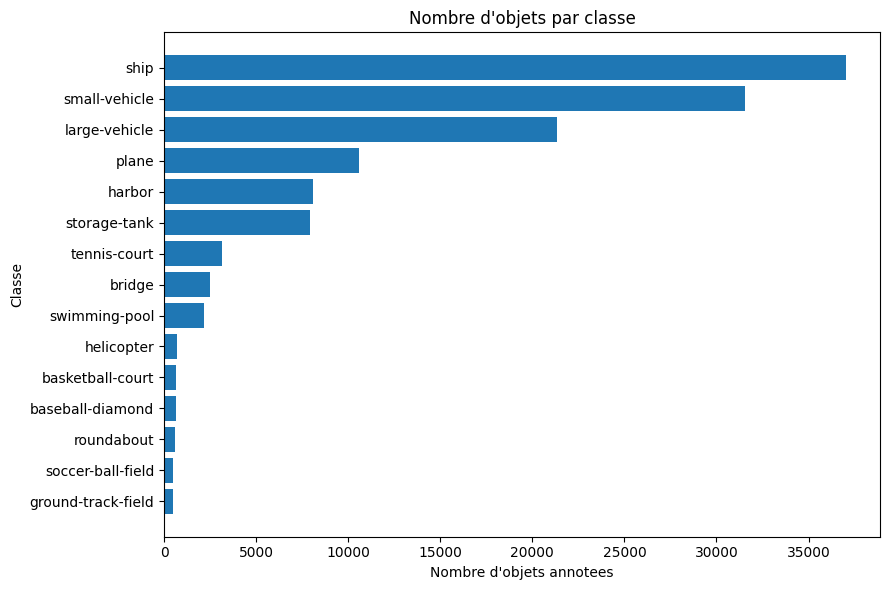

In [105]:
plt.figure(figsize=(9, 6))

# On trie les barres pour faciliter la lecture : les classes les plus frequentes en haut.
plot_data = class_counts.sort_values("n_objects", ascending=True)
plt.barh(plot_data["class_name"], plot_data["n_objects"])

plt.title("Nombre d'objets par classe")
plt.xlabel("Nombre d'objets annotees")
plt.ylabel("Classe")
plt.tight_layout()
plt.show()

On regarde aussi si la repartition des classes est comparable entre l'ensemble d'entrainement et l'ensemble de validation. C'est important parce qu'une validation utile doit ressembler suffisamment aux donnees d'entrainement, tout en restant separee.

In [106]:
# Le parametre normalize='index' transforme les comptes en proportions par ligne.
# Chaque ligne fait donc 100 %, ce qui permet de comparer train et validation.
class_by_split = pd.crosstab(
    objects["split"],
    objects["class_name"],
    normalize="index",
) * 100

class_by_split.round(2)

class_name,baseball-diamond,basketball-court,bridge,ground-track-field,harbor,helicopter,large-vehicle,plane,roundabout,ship,small-vehicle,soccer-ball-field,storage-tank,swimming-pool,tennis-court
split,,,,,,,,,,,,,,,
train,0.42,0.52,2.07,0.33,6.04,0.64,17.14,8.14,0.40,28.35,26.39,0.33,5.08,1.75,2.39
validation,0.74,0.46,1.61,0.50,7.24,0.25,15.20,8.77,0.62,31.05,18.85,0.53,10.01,1.52,2.63


### Objets difficiles

Dans DOTA, la colonne `difficult` indique si un objet est considere difficile a annoter ou a detecter. Ces objets peuvent etre petits, partiellement visibles, tres proches d'autres objets, ou simplement ambigus.

Cette variable est utile pour deux raisons : elle peut aider a interpreter les erreurs du modele, et elle peut devenir plus tard une variable importante dans l'analyse causale.

In [107]:
difficulty_counts = (
    objects.groupby(["split", "difficult"])
    .size()
    .reset_index(name="n_objects")
)

difficulty_counts["percent_in_split"] = difficulty_counts.groupby("split")["n_objects"].transform(
    lambda x: 100 * x / x.sum()
)

difficulty_counts

,split,difficult,n_objects,percent_in_split
0,train,0,93496,94.449944
1,train,1,5494,5.550056
2,validation,0,26944,93.383704
3,validation,1,1909,6.616296


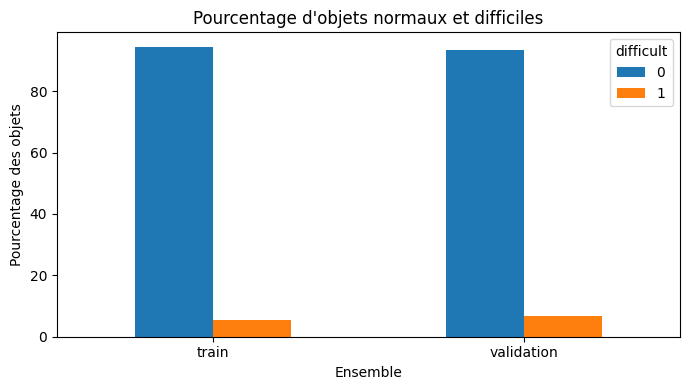

In [108]:
difficulty_pivot = difficulty_counts.pivot(index="split", columns="difficult", values="percent_in_split")

difficulty_pivot.plot(kind="bar", figsize=(7, 4))
plt.title("Pourcentage d'objets normaux et difficiles")
plt.xlabel("Ensemble")
plt.ylabel("Pourcentage des objets")
plt.legend(title="difficult")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Taille des objets

Les annotations DOTA sont des boites orientees, mais on peut deja calculer une boite horizontale englobante avec `xmin`, `ymin`, `xmax`, `ymax`. Cette boite horizontale n'est pas aussi precise que la boite orientee, mais elle donne une premiere approximation de la taille de l'objet.

Ces variables seront utiles pour l'exploration, pour le pretraitement et plus tard pour l'analyse des erreurs du modele.

In [109]:
# Ces variables sont derivees des coordonnees deja calculees.
# Elles ne modifient pas les annotations originales; elles ajoutent seulement des informations utiles.
objects["bbox_width"] = objects["xmax"] - objects["xmin"]
objects["bbox_height"] = objects["ymax"] - objects["ymin"]
objects["bbox_area"] = objects["bbox_width"] * objects["bbox_height"]

objects[["bbox_width", "bbox_height", "bbox_area"]].describe().round(2)

,bbox_width,bbox_height,bbox_area
count,127843.00,127843.00,127843.00
mean,56.12,58.83,7040.32
std,68.66,72.30,37207.35
min,2.00,3.00,9.00
25%,26.00,26.00,756.00
50%,39.00,39.00,1386.00
75%,59.00,62.00,3400.00
max,2402.00,1750.00,2884902.00


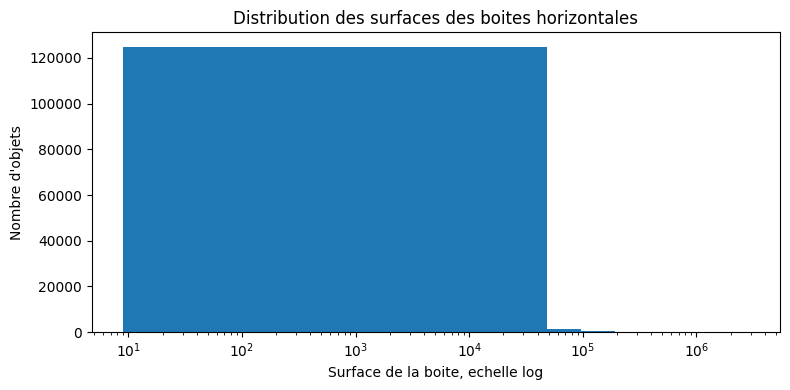

In [110]:
plt.figure(figsize=(8, 4))

# Les surfaces peuvent varier enormement. L'echelle logarithmique rend les petits objets visibles.
plt.hist(objects["bbox_area"], bins=60)
plt.xscale("log")

plt.title("Distribution des surfaces des boites horizontales")
plt.xlabel("Surface de la boite, echelle log")
plt.ylabel("Nombre d'objets")
plt.tight_layout()
plt.show()

### Taille des images

Les images de DOTA ne sont pas toutes de la meme taille. C'est une difference importante avec certains datasets plus simples. Pour entrainer un modele de detection, il faudra souvent redimensionner les images, les decouper en tuiles, ou utiliser un format attendu par le modele.

Avant de decider du pretraitement, on mesure donc la largeur et la hauteur des images.

In [111]:
def load_image_sizes(image_dir, split):
    """Retourne la taille de chaque image PNG dans un dossier."""
    rows = []

    for image_path in sorted(image_dir.glob("*.png")):
        # PIL lit ici les dimensions de l'image sans avoir besoin de l'afficher.
        with Image.open(image_path) as img:
            rows.append(
                {
                    "split": split,
                    "image_id": image_path.stem,
                    "width": img.width,
                    "height": img.height,
                }
            )

    return pd.DataFrame(rows)


train_image_sizes = load_image_sizes(TRAIN_IMG_DIR, "train")
val_image_sizes = load_image_sizes(VAL_IMG_DIR, "validation")
test_image_sizes = load_image_sizes(TEST_IMG_DIR, "test")

image_sizes = pd.concat([train_image_sizes, val_image_sizes, test_image_sizes], ignore_index=True)

image_sizes.groupby("split")[["width", "height"]].agg(["min", "median", "max"])

width                height              
             min  median    max    min  median   max
split                                               
test         211  1817.0  10240    288  1816.0  7665
train        387  1824.0  12029    278  1791.0  8115
validation   353  1871.5  13383    511  1705.5  6759

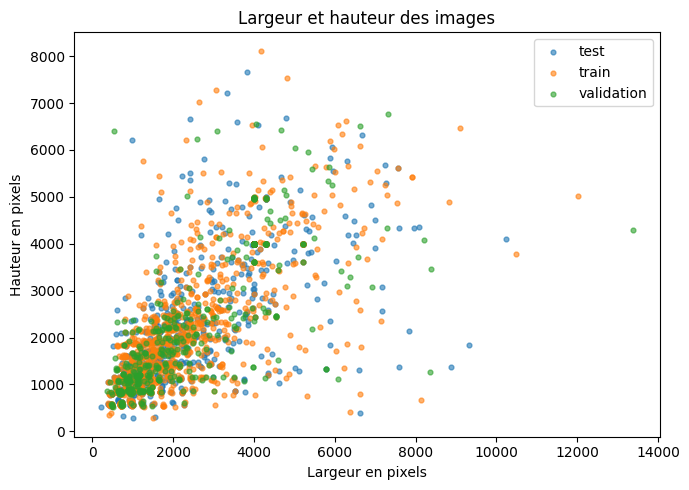

In [112]:
plt.figure(figsize=(7, 5))

for split, group in image_sizes.groupby("split"):
    plt.scatter(group["width"], group["height"], s=12, alpha=0.6, label=split)

plt.title("Largeur et hauteur des images")
plt.xlabel("Largeur en pixels")
plt.ylabel("Hauteur en pixels")
plt.legend()
plt.tight_layout()
plt.show()

### Visualisation des annotations

Les tableaux donnent une vue globale, mais il faut aussi verifier visuellement que les annotations correspondent bien aux objets dans les images. Cela permet de reperer plus facilement les particularites du dataset : objets tres petits, objets nombreux, rotations, densite, ou classes difficiles a distinguer.

La fonction suivante affiche une image avec ses boites orientees.

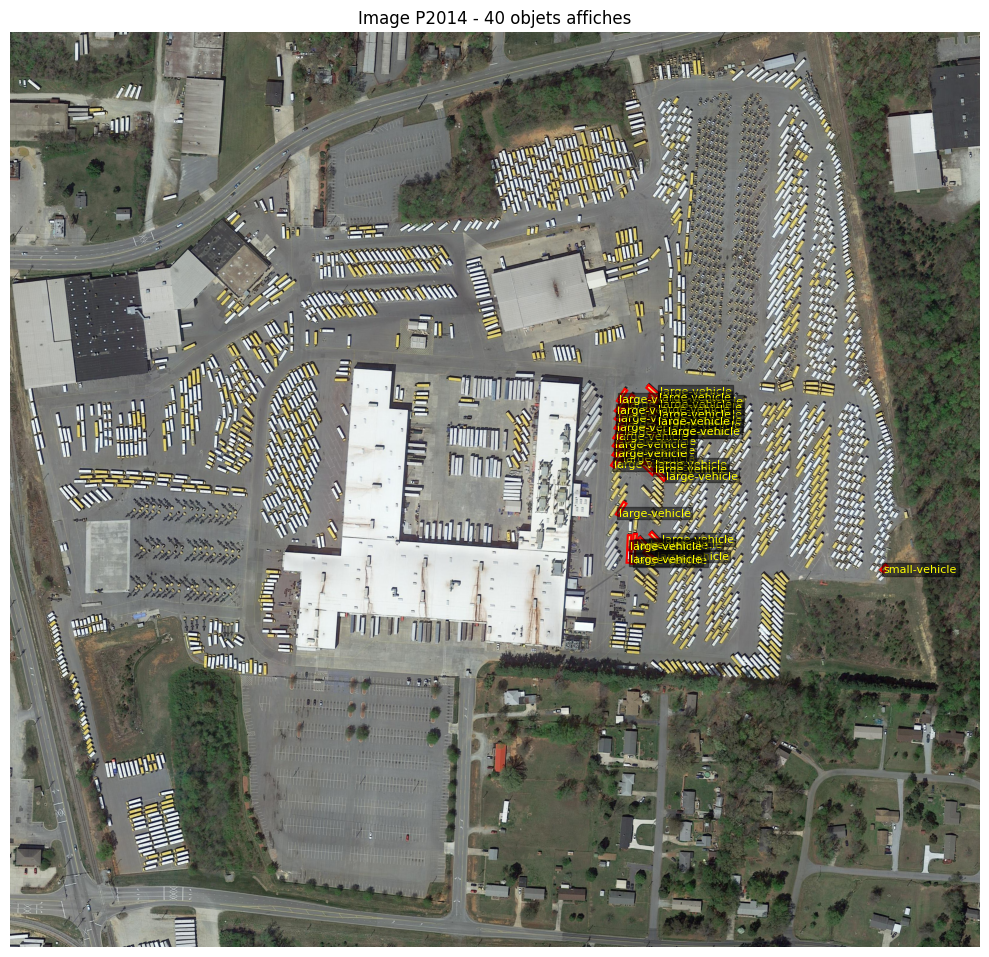

In [113]:
from matplotlib.patches import Polygon


def plot_dota_image_with_boxes(split="train", image_id=None, max_objects=40):
    """Affiche une image DOTA avec un sous-ensemble de ses boites orientees."""
    image_dir = TRAIN_IMG_DIR if split == "train" else VAL_IMG_DIR
    split_objects = objects[objects["split"] == split]

    if image_id is None:
        # On choisit automatiquement une image avec plusieurs objets pour rendre l'exemple parlant.
        image_id = split_objects.groupby("image_id").size().sort_values(ascending=False).index[0]

    image_path = image_dir / f"{image_id}.png"
    image_objects = split_objects[split_objects["image_id"] == image_id].head(max_objects)

    with Image.open(image_path) as img:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(img)

    for _, row in image_objects.iterrows():
        points = [
            (row["x1"], row["y1"]),
            (row["x2"], row["y2"]),
            (row["x3"], row["y3"]),
            (row["x4"], row["y4"]),
        ]

        polygon = Polygon(points, closed=True, fill=False, edgecolor="red", linewidth=1.5)
        ax.add_patch(polygon)
        ax.text(
            row["x1"],
            row["y1"],
            row["class_name"],
            color="yellow",
            fontsize=8,
            bbox={"facecolor": "black", "alpha": 0.45, "pad": 1},
        )

    ax.set_title(f"Image {image_id} - {len(image_objects)} objets affiches")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


plot_dota_image_with_boxes(split="train", max_objects=40)

### Orientation des boites

Une particularite importante de DOTA est que les objets ne sont pas seulement encadres par des rectangles horizontaux. Ils sont souvent tournes : avions, bateaux, vehicules ou terrains de sport peuvent avoir n'importe quelle orientation.

Pour mesurer cela simplement, on estime l'axe principal de chaque boite orientee. L'idee est la suivante : parmi deux cotes consecutifs de la boite, on prend le plus long comme direction principale de l'objet. On convertit ensuite cette direction en angle.

Cette mesure ne sert pas encore a entrainer un modele. Elle sert d'abord a comprendre pourquoi un detecteur capable de gerer les boites orientees peut etre utile sur DOTA.

In [114]:
# On calcule deux cotes consecutifs de la boite orientee : point 1 -> point 2 et point 2 -> point 3.
edge_12_dx = objects["x2"] - objects["x1"]
edge_12_dy = objects["y2"] - objects["y1"]
edge_23_dx = objects["x3"] - objects["x2"]
edge_23_dy = objects["y3"] - objects["y2"]

edge_12_length = np.sqrt(edge_12_dx**2 + edge_12_dy**2)
edge_23_length = np.sqrt(edge_23_dx**2 + edge_23_dy**2)

# Pour avoir une orientation stable, on prend le cote le plus long comme axe principal.
use_edge_12 = edge_12_length >= edge_23_length

objects["obb_long_side"] = np.where(use_edge_12, edge_12_length, edge_23_length)
objects["obb_short_side"] = np.where(use_edge_12, edge_23_length, edge_12_length)

main_dx = np.where(use_edge_12, edge_12_dx, edge_23_dx)
main_dy = np.where(use_edge_12, edge_12_dy, edge_23_dy)

# arctan2 donne un angle en radians. On le transforme en degres entre 0 et 180.
angle_degrees = (np.degrees(np.arctan2(main_dy, main_dx)) + 180) % 180

# L'angle absolu entre 0 et 90 degres suffit pour savoir si l'objet est proche d'un axe ou diagonal.
objects["orientation_deg"] = angle_degrees
objects["orientation_abs_deg"] = np.minimum(angle_degrees, 180 - angle_degrees)

objects[["class_name", "obb_long_side", "obb_short_side", "orientation_deg", "orientation_abs_deg"]].head()

,class_name,obb_long_side,obb_short_side,orientation_deg,orientation_abs_deg
0,plane,110.421918,87.281155,167.977723,12.022277
1,large-vehicle,42.953463,14.317821,24.775141,24.775141
2,large-vehicle,47.423623,10.440307,114.943905,65.056095
3,large-vehicle,49.396356,15.524175,21.370622,21.370622
4,small-vehicle,16.970563,8.246211,135.000000,45.000000


In [115]:
orientation_summary = objects.groupby("split")["orientation_abs_deg"].describe().round(2)
orientation_summary

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
train,98990.0,45.51,30.2,0.0,16.86,47.17,73.17,90.0
validation,28853.0,48.67,32.6,0.0,15.95,52.28,81.51,90.0


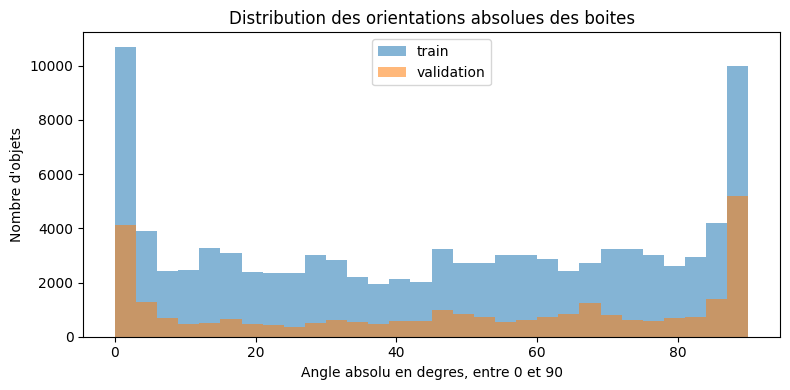

In [116]:
plt.figure(figsize=(8, 4))

bins = np.linspace(0, 90, 31)

for split, group in objects.groupby("split"):
    plt.hist(group["orientation_abs_deg"], bins=bins, alpha=0.55, label=split)

plt.title("Distribution des orientations absolues des boites")
plt.xlabel("Angle absolu en degres, entre 0 et 90")
plt.ylabel("Nombre d'objets")
plt.legend()
plt.tight_layout()
plt.show()

Un angle proche de 0 signifie que l'axe principal de l'objet est presque horizontal. Un angle proche de 90 signifie qu'il est presque vertical. Un angle autour de 45 correspond a un objet tres diagonal.

Cette information est importante pour la suite. Si beaucoup d'objets sont fortement orientes, convertir toutes les boites en rectangles horizontaux peut ajouter beaucoup de fond autour des objets. Cela peut rendre l'apprentissage moins precis, surtout pour les objets longs et fins comme les bateaux, les ponts ou certains vehicules.

### Algorithmes envisageables

A ce stade, on ne choisit pas encore definitivement le modele. On identifie plutot les familles de methodes qui correspondent au probleme.

**YOLO-OBB** est une option tres pertinente pour DOTA, car elle peut apprendre des boites orientees. Son avantage est qu'elle respecte mieux la geometrie des objets aeriens. Son inconvenient est qu'il faut convertir les annotations DOTA dans le format attendu et verifier que l'environnement GPU fonctionne correctement.

**Faster R-CNN, RetinaNet ou YOLO avec boites horizontales** sont des options plus classiques. Elles sont souvent plus faciles a expliquer et a relier aux notions standards de detection. Leur limite est qu'une boite horizontale peut etre moins precise qu'une boite orientee pour les objets tournes.

**DETR** est un detecteur moderne, mais il peut etre plus lourd a entrainer et moins ideal pour une premiere version realiste du projet. Il est interessant a mentionner, mais ce ne serait pas mon premier choix pratique ici.

**Arbres causaux ou forets causales** ne sont pas des detecteurs d'objets. Ils seront utiles plus tard, apres l'entrainement du detecteur, pour etudier si certaines conditions comme la petite taille, l'orientation ou la densite augmentent le risque d'erreur.

Un algorithme inadapte serait un simple classifieur d'image qui donne une seule classe pour toute l'image. DOTA contient souvent plusieurs objets de classes differentes dans la meme image, et le probleme demande de localiser chaque objet. Un classifieur global ne produit donc pas les boites et ne repond pas a la tache de detection.

### Risques methodologiques a garder en tete

Le premier risque est la fuite de donnees pendant le tuilage. Si on decoupe une grande image en tuiles, toutes les tuiles issues de cette image doivent rester dans le meme ensemble. Sinon, le modele pourrait voir une partie d'une image en entrainement et une autre partie tres proche en validation, ce qui donnerait une evaluation trop optimiste.

Le deuxieme risque est le desequilibre des classes. Certaines classes comme `ship`, `small-vehicle` et `large-vehicle` sont beaucoup plus frequentes. Un modele peut donc obtenir de bons scores globaux tout en restant faible sur des classes rares.

Le troisieme risque est la perte d'information si on convertit les boites orientees en boites horizontales. Cette conversion peut etre acceptable pour simplifier une premiere version, mais elle doit etre justifiee parce qu'elle rend les objets tournes moins bien localises.

Le dernier risque est de confondre prediction et causalite. Un detecteur peut montrer que les petits objets sont moins bien detectes, mais cela ne prouve pas automatiquement un effet causal de la taille. Pour parler de causalite, il faudra definir un traitement, une sortie, des variables d'ajustement et des hypotheses.

### Bilan provisoire de l'exploration

Cette premiere exploration montre plusieurs points qui vont guider la suite :

- les classes ne sont pas equilibrees ;
- certains objets sont marques comme difficiles ;
- les objets ont des tailles tres variables ;
- les images ont aussi des dimensions tres variables ;
- les boites orientees sont importantes, car les objets peuvent etre tournes dans n'importe quelle direction ;
- les algorithmes doivent etre choisis en fonction de la tache de detection, pas seulement parce qu'ils sont populaires ;
- la suite devra eviter les fuites entre tuiles et distinguer clairement evaluation predictive et analyse causale.

La suite logique sera le pretraitement : preparer les annotations et les images dans un format compatible avec les modeles de detection que l'on choisira. La decision importante sera de choisir entre conserver les boites orientees, par exemple avec YOLO-OBB, ou utiliser des boites horizontales avec une justification claire.

### Mini-exemple : descente de gradient stochastique

Le bloc suivant n'est pas encore un modele de detection pour DOTA. C'est un petit exemple pedagogique pour comprendre une idee centrale de l'apprentissage automatique : ajuster une valeur petit a petit pour minimiser une erreur.

Ici, on utilise la fonction simple `f(x) = x^2`. Son minimum est en `x = 0`, car `0^2 = 0`. La descente de gradient part de `x = 10`, calcule dans quelle direction la fonction augmente, puis bouge dans la direction opposee pour se rapprocher du minimum.

Le mot "stochastique" signifie qu'on ajoute un peu de hasard au gradient. Cela imite ce qui se passe en machine learning : on n'utilise pas toujours toutes les donnees pour calculer une mise a jour parfaite, donc les mises a jour peuvent etre un peu bruitees.

A retenir : ce bloc sert a visualiser le principe d'optimisation. Plus tard, lorsqu'on entrainera un detecteur, le modele fera la meme idee generale, mais avec des millions de parametres au lieu d'une seule valeur `x`.

Epochs: 20
Final x: -0.015418189621545928


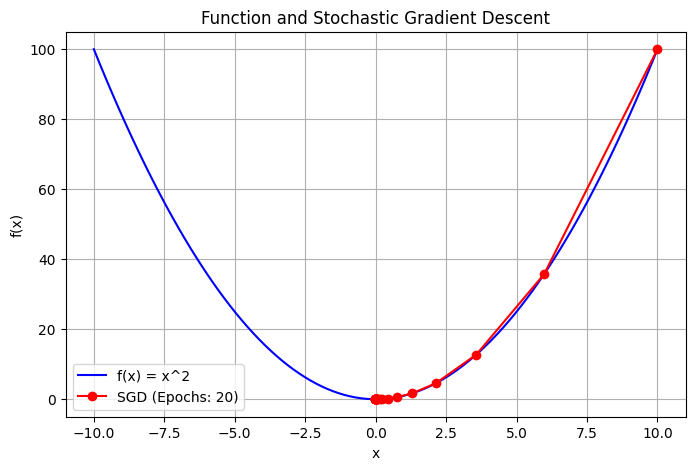

In [117]:
import numpy as np
import matplotlib.pyplot as plt

def sgd(eta, noise_scale=0.1):
    x = 10
    results = [x]
    gradients = [2 * x]
    for i in range(20): 
# un seul exemple (echantillon) aleatoire,
# comme en apprentissage automatique, ou le gradient varie d'un echantillon a l'autre.  
        noise = np.random.randn() * noise_scale
        gradient = 2 * x + noise
        x -= eta * gradient
        results.append(x)
        gradients.append(gradient)
        # Check if the difference between consecutive gradients is below a threshold to stop
        if i > 0 and abs(gradients[i] - gradients[i-1]) < 1e-6:
            break
    print('Epochs:', len(results)-1)
    print('Final x:', x)
    return results, gradients

res, grads = sgd(0.2)

# Plotting the function f(x) = x^2
x_vals = np.linspace(-10, 10, 100)
y_vals = x_vals ** 2
plt.plot(x_vals, y_vals, label='f(x) = x^2', color='blue')

# Plotting the stochastic gradient descent path
epochs = len(res)-1
plt.plot(res, [x**2 for x in res], 'ro-', label='SGD (Epochs: {})'.format(epochs))
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function and Stochastic Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

## 2. Pretraitement des images, annotations et variables derivees

Le pretraitement sert a transformer les donnees brutes en donnees utilisables par les modeles.

Pour DOTA, on doit faire attention a deux choses :

- les annotations originales sont des boites orientees, donc il ne faut pas les perdre trop vite ;
- les modeles demandent souvent des coordonnees normalisees entre `0` et `1`, pas des pixels bruts.

Decision provisoire pour ce projet : on garde les boites orientees comme information principale, parce que l'exploration a montre que les objets sont souvent tournes. En parallele, on prepare aussi des boites horizontales derivees. Elles pourront servir pour une baseline plus simple ou pour l'analyse des erreurs.

### Encodage des classes

Les annotations DOTA utilisent des noms de classes comme `ship`, `plane` ou `small-vehicle`. Un modele de deep learning travaille plus facilement avec des entiers : `0`, `1`, `2`, etc.

On cree donc un dictionnaire `class_to_id` qui associe chaque nom de classe a un identifiant numerique. On utilise l'ordre DOTA couramment repris par Ultralytics pour rester compatible avec les exemples YOLO-OBB. On cree aussi le dictionnaire inverse `id_to_class` pour pouvoir relire les predictions plus tard.

In [118]:
DOTA_V1_CLASSES = [
    "plane",
    "ship",
    "storage-tank",
    "baseball-diamond",
    "tennis-court",
    "basketball-court",
    "ground-track-field",
    "harbor",
    "bridge",
    "large-vehicle",
    "small-vehicle",
    "helicopter",
    "roundabout",
    "soccer-ball-field",
    "swimming-pool",
]

classes_in_data = sorted(objects["class_name"].unique())
unknown_classes = sorted(set(classes_in_data) - set(DOTA_V1_CLASSES))
classes_absent_from_data = sorted(set(DOTA_V1_CLASSES) - set(classes_in_data))

if unknown_classes:
    raise ValueError(f"Classes inconnues dans les annotations : {unknown_classes}")

class_names = DOTA_V1_CLASSES
class_to_id = {class_name: idx for idx, class_name in enumerate(class_names)}
id_to_class = {idx: class_name for class_name, idx in class_to_id.items()}

print("Nombre de classes :", len(class_names))
print("Classes absentes des annotations chargees :", classes_absent_from_data)

pd.DataFrame(
    [{"class_id": class_to_id[class_name], "class_name": class_name} for class_name in class_names]
)

Nombre de classes : 15
Classes absentes des annotations chargees : []


,class_id,class_name
0,0,plane
1,1,ship
2,2,storage-tank
3,3,baseball-diamond
4,4,tennis-court
5,5,basketball-court
6,6,ground-track-field
7,7,harbor
8,8,bridge
9,9,large-vehicle


### Association des annotations avec la taille des images

Pour normaliser une coordonnee, il faut connaitre la taille de l'image.

Exemple : si une image fait `2000` pixels de large et qu'un point a `x = 500`, alors la coordonnee normalisee vaut `500 / 2000 = 0.25`.

On fusionne donc le tableau des objets avec le tableau des tailles d'images.

In [119]:
image_sizes_for_annotations = image_sizes[image_sizes["split"].isin(["train", "validation"])]

preprocessed_objects = objects.merge(
    image_sizes_for_annotations,
    on=["split", "image_id"],
    how="left",
    validate="many_to_one",
)

preprocessed_objects["class_id"] = preprocessed_objects["class_name"].map(class_to_id)

missing_image_size = preprocessed_objects[["width", "height"]].isna().any(axis=1).sum()
missing_class_id = preprocessed_objects["class_id"].isna().sum()

print("Objets apres fusion       :", len(preprocessed_objects))
print("Tailles d'image manquantes:", missing_image_size)
print("Classes non encodees      :", missing_class_id)

preprocessed_objects[["split", "image_id", "class_name", "class_id", "width", "height"]].head()

Objets apres fusion       : 127843
Tailles d'image manquantes: 0
Classes non encodees      : 0


,split,image_id,class_name,class_id,width,height
0,train,P0000,plane,0,3875,5502
1,train,P0000,large-vehicle,9,3875,5502
2,train,P0000,large-vehicle,9,3875,5502
3,train,P0000,large-vehicle,9,3875,5502
4,train,P0000,small-vehicle,10,3875,5502


### Normalisation des coordonnees

Les fichiers DOTA donnent les coordonnees en pixels. C'est pratique pour afficher les boites sur les images, mais beaucoup de formats de detection utilisent des coordonnees normalisees.

On va creer deux representations derivees :

- `obb_*_norm` : les 8 coordonnees de la boite orientee, normalisees entre `0` et `1` ;
- `yolo_x_center`, `yolo_y_center`, `yolo_width`, `yolo_height` : la boite horizontale englobante au format centre-largeur-hauteur, aussi normalisee.

La boite orientee garde mieux la geometrie reelle. La boite horizontale est plus simple, mais elle peut contenir beaucoup de fond autour d'un objet tourne.

In [120]:
x_cols = ["x1", "x2", "x3", "x4", "xmin", "xmax"]
y_cols = ["y1", "y2", "y3", "y4", "ymin", "ymax"]

for col in x_cols:
    preprocessed_objects[f"{col}_norm"] = preprocessed_objects[col] / preprocessed_objects["width"]

for col in y_cols:
    preprocessed_objects[f"{col}_norm"] = preprocessed_objects[col] / preprocessed_objects["height"]

# Format horizontal centre-largeur-hauteur, proche du format attendu par plusieurs detecteurs.
preprocessed_objects["yolo_x_center"] = (preprocessed_objects["xmin"] + preprocessed_objects["xmax"]) / 2 / preprocessed_objects["width"]
preprocessed_objects["yolo_y_center"] = (preprocessed_objects["ymin"] + preprocessed_objects["ymax"]) / 2 / preprocessed_objects["height"]
preprocessed_objects["yolo_width"] = preprocessed_objects["bbox_width"] / preprocessed_objects["width"]
preprocessed_objects["yolo_height"] = preprocessed_objects["bbox_height"] / preprocessed_objects["height"]

preview_cols = [
    "class_name", "class_id",
    "x1_norm", "y1_norm", "x2_norm", "y2_norm", "x3_norm", "y3_norm", "x4_norm", "y4_norm",
    "yolo_x_center", "yolo_y_center", "yolo_width", "yolo_height",
]

preprocessed_objects[preview_cols].head().round(4)

,class_name,class_id,x1_norm,y1_norm,x2_norm,y2_norm,x3_norm,y3_norm,x4_norm,y4_norm,yolo_x_center,yolo_y_center,yolo_width,yolo_height
0,plane,0,0.7105,0.4377,0.7383,0.4335,0.7453,0.4486,0.7239,0.4547,0.7279,0.4441,0.0348,0.0213
1,large-vehicle,9,0.8890,0.6163,0.8991,0.6196,0.8975,0.6220,0.8870,0.6183,0.8930,0.6191,0.0121,0.0056
2,large-vehicle,9,0.8219,0.7557,0.8245,0.7563,0.8194,0.7641,0.8165,0.7632,0.8205,0.7599,0.0080,0.0084
3,large-vehicle,9,0.7406,0.7724,0.7525,0.7757,0.7515,0.7784,0.7396,0.7748,0.7461,0.7754,0.0129,0.0060
4,small-vehicle,10,0.1626,0.3043,0.1621,0.3028,0.1652,0.3006,0.1662,0.3028,0.1641,0.3024,0.0041,0.0036


### Controle qualite du pretraitement

Avant d'ecrire des fichiers pour un modele, on verifie que les transformations sont coherentes.

On veut surtout savoir :

- si certaines boites ont une largeur ou une hauteur non positive ;
- si certaines coordonnees normalisees sortent de l'intervalle `[0, 1]` ;
- si le nombre d'objets reste identique apres les transformations.

Des coordonnees legerement hors image peuvent arriver dans certains datasets, mais il faut les detecter avant l'entrainement.

In [121]:
normalized_coordinate_cols = [
    "x1_norm", "y1_norm", "x2_norm", "y2_norm", "x3_norm", "y3_norm", "x4_norm", "y4_norm",
    "yolo_x_center", "yolo_y_center", "yolo_width", "yolo_height",
]

invalid_size = (preprocessed_objects["bbox_width"] <= 0) | (preprocessed_objects["bbox_height"] <= 0)
outside_normalized_range = (
    (preprocessed_objects[normalized_coordinate_cols] < 0)
    | (preprocessed_objects[normalized_coordinate_cols] > 1)
).any(axis=1)

quality_summary = pd.DataFrame(
    [
        {"controle": "objets total", "nombre": len(preprocessed_objects)},
        {"controle": "boites largeur/hauteur non positives", "nombre": int(invalid_size.sum())},
        {"controle": "coordonnees normalisees hors [0, 1]", "nombre": int(outside_normalized_range.sum())},
    ]
)

quality_summary

,controle,nombre
0,objets total,127843
1,boites largeur/hauteur non positives,0
2,"coordonnees normalisees hors [0, 1]",171


### Details des annotations a verifier

Quand une coordonnee normalisee sort de `[0, 1]`, cela veut dire qu'au moins un coin de la boite est en dehors de l'image selon les dimensions lues avec PIL.

Il y a deux cas possibles :

- un petit depassement, par exemple `1.0007`, souvent lie a un objet colle au bord de l'image ou a une convention d'arrondi ;
- un grand depassement, par exemple `2.5`, qui suggere plutot une annotation ou une image a verifier.

On ne corrige pas silencieusement ces cas. On les isole pour savoir ce qui serait exclu ou traite separement avant l'entrainement.

In [122]:
preprocessed_objects["min_normalized_coord"] = preprocessed_objects[normalized_coordinate_cols].min(axis=1)
preprocessed_objects["max_normalized_coord"] = preprocessed_objects[normalized_coordinate_cols].max(axis=1)

minor_outside_range = outside_normalized_range & (
    preprocessed_objects["min_normalized_coord"].between(-0.01, 1.01)
    & preprocessed_objects["max_normalized_coord"].between(-0.01, 1.01)
)
major_outside_range = outside_normalized_range & ~minor_outside_range

normalization_issue_summary = pd.DataFrame(
    [
        {"type": "aucun probleme", "nombre": int((~outside_normalized_range).sum())},
        {"type": "petit depassement", "nombre": int(minor_outside_range.sum())},
        {"type": "grand depassement", "nombre": int(major_outside_range.sum())},
    ]
)

normalization_issue_summary

,type,nombre
0,aucun probleme,127672
1,petit depassement,87
2,grand depassement,84


In [123]:
objects_to_verify = preprocessed_objects[outside_normalized_range].copy()

issue_by_image = (
    objects_to_verify.groupby(["split", "image_id"])
    .size()
    .reset_index(name="objects_to_verify")
    .sort_values("objects_to_verify", ascending=False)
)

display_cols = [
    "split", "image_id", "class_name", "xmin", "ymin", "xmax", "ymax",
    "width", "height", "min_normalized_coord", "max_normalized_coord",
]

print("Images avec le plus d'objets a verifier :")
print(issue_by_image.head(10).to_string(index=False))

print("\nExemples d'annotations a verifier :")
print(objects_to_verify[display_cols].sort_values("max_normalized_coord", ascending=False).head(10).round(4).to_string(index=False))

Images avec le plus d'objets a verifier :
     split image_id  objects_to_verify
     train    P1872                 84
     train    P1071                  3
     train    P0713                  2
validation    P1787                  2
     train    P0760                  2
     train    P1805                  2
     train    P1848                  2
     train    P1793                  2
     train    P0383                  1
     train    P0013                  1

Exemples d'annotations a verifier :
split image_id class_name    xmin   ymin    xmax   ymax  width  height  min_normalized_coord  max_normalized_coord
train    P1872      plane 11590.0  204.0 11782.0  418.0   4033    4996                0.0408                2.9214
train    P1872      plane 11568.0 1000.0 11688.0 1114.0   4033    4996                0.0228                2.8981
train    P1872      plane 11362.0  816.0 11500.0  962.0   4033    4996                0.0292                2.8515
train    P1872      plane 11300.

### Sous-ensemble pret pour un premier export

Pour un premier pipeline simple, on cree un sous-ensemble `training_ready_objects` qui exclut les boites invalides ou hors image.

Ce choix est conservateur : on ne supprime rien des donnees originales, mais on evite d'envoyer au modele des annotations qui pourraient faire echouer l'entrainement ou produire des labels invalides.

Plus tard, on pourra revenir sur ces objets exclus pour decider s'il faut les clipper, les corriger manuellement, exclure certaines images, ou les garder pour une analyse des erreurs.

In [124]:
training_ready_mask = (~invalid_size) & (~outside_normalized_range)

training_ready_objects = preprocessed_objects[training_ready_mask].copy()
excluded_objects = preprocessed_objects[~training_ready_mask].copy()

ready_summary = pd.DataFrame(
    [
        {"ensemble": "objets utilisables", "nombre": len(training_ready_objects)},
        {"ensemble": "objets exclus provisoirement", "nombre": len(excluded_objects)},
    ]
)
ready_summary["pourcentage"] = (ready_summary["nombre"] / len(preprocessed_objects) * 100).round(3)

ready_summary

,ensemble,nombre,pourcentage
0,objets utilisables,127672,99.866
1,objets exclus provisoirement,171,0.134


### Interpretation provisoire

A ce stade, on n'a pas encore modifie les images et on n'a pas encore cree de tuiles. On a seulement prepare un tableau propre qui relie chaque objet a sa classe numerique, a la taille de son image, a ses coordonnees orientees normalisees et a une boite horizontale derivee.

La prochaine decision importante sera le format d'entrainement :

- soit exporter les annotations orientees pour un modele de type YOLO-OBB ;
- soit exporter les boites horizontales pour une baseline plus simple ;
- soit faire les deux, ce qui permettrait de comparer simplicite et precision geometrique.

Pour eviter les fuites de donnees, le tuilage viendra seulement apres cette decision, et les tuiles issues d'une meme image resteront toujours dans le meme ensemble.

### Export provisoire au format YOLO-OBB

Pour la suite du projet, le format le plus coherent est YOLO-OBB, car il garde les quatre coins de la boite orientee.

Documentation Ultralytics consultee le 2026-07-08 : https://docs.ultralytics.com/datasets/obb/

Le format attendu dans un fichier label est :

`class_index x1 y1 x2 y2 x3 y3 x4 y4`

Chaque coordonnee doit etre normalisee entre `0` et `1`. C'est exactement ce que nous avons prepare dans `training_ready_objects`.

Dans un premier temps, on exporte seulement les fichiers labels. On ne copie pas encore les images, car les images DOTA sont volumineuses. Plus tard, pour lancer l'entrainement avec Ultralytics, il faudra creer les dossiers `images/train` et `images/val`, soit avec des liens vers les images originales, soit avec des copies.

In [125]:
YOLO_OBB_DIR = PROJECT_DIR / "prepared_data" / "dota_yolo_obb"

YOLO_OBB_LABEL_DIRS = {
    "train": YOLO_OBB_DIR / "labels" / "train",
    "validation": YOLO_OBB_DIR / "labels" / "val",
}

YOLO_OBB_IMAGE_DIRS = {
    "train": YOLO_OBB_DIR / "images" / "train",
    "validation": YOLO_OBB_DIR / "images" / "val",
}

YOLO_OBB_DIR

WindowsPath('c:/Users/Tazi/Desktop/School/Projet/dota-minimap-object-detection/prepared_data/dota_yolo_obb')

In [126]:
def format_yolo_obb_row(row):
    """Transforme une annotation en une ligne YOLO-OBB."""
    coords = [
        row["x1_norm"], row["y1_norm"],
        row["x2_norm"], row["y2_norm"],
        row["x3_norm"], row["y3_norm"],
        row["x4_norm"], row["y4_norm"],
    ]
    coord_text = " ".join(f"{value:.6f}" for value in coords)
    return f"{int(row['class_id'])} {coord_text}"


def export_yolo_obb_labels(objects_df, label_dirs):
    """Ecrit un fichier .txt par image au format YOLO-OBB."""
    summaries = []

    for split, label_dir in label_dirs.items():
        label_dir.mkdir(parents=True, exist_ok=True)

        # Les labels sont generes par le notebook; on nettoie donc les anciens labels de ce dossier genere.
        for old_label_path in label_dir.glob("*.txt"):
            old_label_path.unlink()

        split_objects = objects_df[objects_df["split"] == split]

        for image_id, group in split_objects.groupby("image_id"):
            lines = [format_yolo_obb_row(row) for _, row in group.iterrows()]
            label_path = label_dir / f"{image_id}.txt"
            label_path.write_text("\n".join(lines) + "\n", encoding="utf-8")

        summaries.append(
            {
                "split": split,
                "images_avec_labels": split_objects["image_id"].nunique(),
                "objets_exportes": len(split_objects),
                "dossier_labels": str(label_dir),
            }
        )

    return pd.DataFrame(summaries)


In [ ]:
yolo_obb_export_summary = export_yolo_obb_labels(training_ready_objects, YOLO_OBB_LABEL_DIRS)
yolo_obb_export_summary

### Fichier YAML du dataset

Ultralytics utilise un fichier YAML pour savoir ou sont les images, ou sont les labels et quelles sont les classes.

Le fichier YAML ci-dessous pointe vers une structure standard :

- `images/train` pour les images d'entrainement ;
- `images/val` pour les images de validation ;
- `labels/train` et `labels/val` pour les labels correspondants.

Pour l'instant, les labels existent. Les images seront ajoutees plus tard avec des liens ou des copies, au moment de lancer un vrai entrainement.

In [ ]:
YOLO_OBB_YAML_PATH = YOLO_OBB_DIR / "dota_yolo_obb.yaml"

yaml_lines = [
    f"path: {YOLO_OBB_DIR.as_posix()}",
    "train: images/train",
    "val: images/val",
    "names:",
]

for class_id, class_name in id_to_class.items():
    yaml_lines.append(f"  {class_id}: {class_name}")

YOLO_OBB_YAML_PATH.write_text("\n".join(yaml_lines) + "\n", encoding="utf-8")

print(YOLO_OBB_YAML_PATH)
print(YOLO_OBB_YAML_PATH.read_text(encoding="utf-8"))

c:\Users\Tazi\Desktop\School\Projet\dota-minimap-object-detection\prepared_data\dota_yolo_obb\dota_yolo_obb.yaml
path: c:/Users/Tazi/Desktop/School/Projet/dota-minimap-object-detection/prepared_data/dota_yolo_obb
train: images/train
val: images/val
names:
  0: plane
  1: ship
  2: storage-tank
  3: baseball-diamond
  4: tennis-court
  5: basketball-court
  6: ground-track-field
  7: harbor
  8: bridge
  9: large-vehicle
  10: small-vehicle
  11: helicopter
  12: roundabout
  13: soccer-ball-field
  14: swimming-pool



### Preparation optionnelle des images

La cellule suivante est volontairement desactivee par defaut avec `CREATE_IMAGE_LINKS = False`.

Pourquoi ? Parce que creer des copies de toutes les images peut prendre beaucoup d'espace disque. Quand on sera pret a entrainer, on pourra passer cette variable a `True`. Le code essaiera d'abord de creer des liens durs vers les images originales. Si ce n'est pas possible, il fera une copie.

Cela permet d'avoir la structure attendue par YOLO sans dupliquer inutilement le dataset quand le systeme accepte les liens durs.

In [ ]:
import os
import shutil


def link_or_copy_image(source_path, target_path):
    target_path.parent.mkdir(parents=True, exist_ok=True)

    if target_path.exists():
        return "deja present"

    try:
        os.link(source_path, target_path)
        return "lien dur"
    except OSError:
        shutil.copy2(source_path, target_path)
        return "copie"


def prepare_yolo_image_folder(objects_df, split, source_image_dir, target_image_dir):
    image_ids = sorted(objects_df.loc[objects_df["split"] == split, "image_id"].unique())
    counts = {"deja present": 0, "lien dur": 0, "copie": 0, "manquant": 0}

    for image_id in image_ids:
        source_path = source_image_dir / f"{image_id}.png"
        target_path = target_image_dir / f"{image_id}.png"

        if not source_path.exists():
            counts["manquant"] += 1
            continue

        result = link_or_copy_image(source_path, target_path)
        counts[result] += 1

    return {"split": split, **counts}


CREATE_IMAGE_LINKS = False

if CREATE_IMAGE_LINKS:
    image_link_summary = pd.DataFrame(
        [
            prepare_yolo_image_folder(training_ready_objects, "train", TRAIN_IMG_DIR, YOLO_OBB_IMAGE_DIRS["train"]),
            prepare_yolo_image_folder(training_ready_objects, "validation", VAL_IMG_DIR, YOLO_OBB_IMAGE_DIRS["validation"]),
        ]
    )
else:
    image_link_summary = pd.DataFrame(
        [{"message": "Images non preparees. Mettre CREATE_IMAGE_LINKS = True avant l'entrainement."}]
    )

image_link_summary

,message
0,Images non preparees. Mettre CREATE_IMAGE_LINK...


In [ ]:
export_check = pd.DataFrame(
    [
        {"element": "labels/train", "existe": YOLO_OBB_LABEL_DIRS["train"].exists(), "nb_fichiers": count_files(YOLO_OBB_LABEL_DIRS["train"], "*.txt")},
        {"element": "labels/val", "existe": YOLO_OBB_LABEL_DIRS["validation"].exists(), "nb_fichiers": count_files(YOLO_OBB_LABEL_DIRS["validation"], "*.txt")},
        {"element": "images/train", "existe": YOLO_OBB_IMAGE_DIRS["train"].exists(), "nb_fichiers": count_files(YOLO_OBB_IMAGE_DIRS["train"], "*.png")},
        {"element": "images/val", "existe": YOLO_OBB_IMAGE_DIRS["validation"].exists(), "nb_fichiers": count_files(YOLO_OBB_IMAGE_DIRS["validation"], "*.png")},
        {"element": "yaml", "existe": YOLO_OBB_YAML_PATH.exists(), "nb_fichiers": int(YOLO_OBB_YAML_PATH.exists())},
    ]
)

export_check

,element,existe,nb_fichiers
0,labels/train,True,1407
1,labels/val,True,456
2,images/train,False,0
3,images/val,False,0
4,yaml,True,1


### Interpretation de l'export

Nous avons maintenant les labels YOLO-OBB et le fichier YAML du dataset. Ce n'est pas encore l'entrainement du modele, mais c'est une etape necessaire avant l'entrainement.

Ce que le modele recevra plus tard :

- une image en entree ;
- des objets a predire ;
- pour chaque objet, une classe et une boite orientee ;
- une fonction de perte qui penalise les erreurs de classe et de localisation.

Pour la presentation intermediaire, cette section est utile parce qu'elle montre que le choix de YOLO-OBB n'est pas arbitraire : il vient directement de la structure des annotations DOTA et de l'analyse des orientations.

## 3. Modele predictif envisage : YOLO-OBB

Avant d'entrainer un modele, il faut comprendre ce que l'algorithme essaie d'apprendre.

Dans ce projet, le modele principal envisage est **YOLO-OBB**. YOLO est une famille de detecteurs d'objets rapides. OBB signifie *Oriented Bounding Box*, donc boite englobante orientee.

L'idee generale : a partir d'une image, le modele doit predire plusieurs objets. Pour chaque objet, il doit predire :

- la classe de l'objet, par exemple `plane`, `ship` ou `small-vehicle` ;
- la position de l'objet dans l'image ;
- dans notre cas, l'orientation de la boite, parce que les objets dans DOTA peuvent etre tournes.

### Comment fonctionne YOLO ?

YOLO veut dire *You Only Look Once*. Le nom vient de l'idee suivante : le modele regarde l'image une seule fois avec un reseau de neurones, puis produit directement les detections.

Un detecteur YOLO moderne contient generalement trois parties :

1. **Backbone** : extrait des caracteristiques visuelles de l'image. Par exemple, il apprend a reperer des textures, des contours, des formes et des motifs.
2. **Neck** : combine les caracteristiques a plusieurs echelles. C'est important parce que certains objets sont petits, comme des vehicules, et d'autres sont grands, comme des terrains ou des ponts.
3. **Head** : produit les predictions finales : classes, boites et scores de confiance.

La sortie du modele n'est pas une seule classe pour toute l'image. C'est une liste de detections candidates. Chaque detection contient une classe, une boite et un score de confiance.

Ensuite, une etape de filtrage supprime les predictions trop faibles et evite de garder plusieurs boites presque identiques pour le meme objet.

### Difference entre YOLO classique et YOLO-OBB

Un YOLO classique predit souvent des boites horizontales, de type `(x_center, y_center, width, height)`. Ces boites restent alignees avec les axes de l'image.

YOLO-OBB ajoute l'orientation. Il peut representer une boite tournee, soit avec quatre coins, soit avec un format interne centre-largeur-hauteur-rotation.

Pour DOTA, cette difference est importante :

- un avion peut etre diagonal ;
- un bateau peut etre tourne dans n'importe quelle direction ;
- un pont ou un terrain peut ne pas etre aligne avec l'image.

Si on utilise une boite horizontale pour ces objets, la boite contient souvent beaucoup de fond inutile. Cela peut rendre la localisation moins precise et fausser certaines analyses d'erreurs.

Avec une boite orientee, la boite suit mieux la forme reelle de l'objet.

### Ce que le modele apprend pendant l'entrainement

Pendant l'entrainement, le modele compare ses predictions aux annotations connues.

Il apprend a reduire plusieurs types d'erreurs :

- **erreur de classification** : mauvaise classe predite ;
- **erreur de localisation** : boite mal placee ;
- **erreur d'orientation** : boite tournee dans une mauvaise direction ;
- **erreur de confiance** : le modele est trop confiant ou pas assez confiant.

Ces erreurs sont combinees dans une fonction de perte. L'optimiseur ajuste ensuite les poids du reseau pour diminuer cette perte.

Le mini-exemple de descente de gradient vu plus haut illustre cette idee generale : on ajuste progressivement des parametres pour minimiser une erreur. Dans YOLO-OBB, il n'y a pas une seule variable `x`, mais des millions de poids dans le reseau.

### Pourquoi YOLO-OBB est adapte a ce projet

YOLO-OBB est un bon candidat pour ce projet pour quatre raisons :

1. Le projet est un probleme de detection d'objets, pas de classification globale d'image.
2. DOTA fournit des boites orientees, donc utiliser un modele OBB respecte mieux les annotations originales.
3. Les images aeriennes contiennent beaucoup d'objets petits et orientes.
4. YOLO est assez pratique pour construire un premier pipeline complet dans un temps raisonnable.

Limites a garder en tete :

- il faut convertir les annotations proprement ;
- il faut verifier l'environnement GPU ;
- les tres grandes images DOTA devront probablement etre decoupees en tuiles ;
- les classes rares peuvent rester difficiles meme avec un modele moderne.

Pour la presentation, la phrase centrale a retenir est : **j'utilise YOLO-OBB parce que mon dataset ne contient pas seulement des objets a classer, mais des objets a localiser avec une orientation precise**.

### Verification de l'environnement d'entrainement

Avant de lancer un entrainement profond, il faut verifier l'environnement Python.

Les points importants sont :

- est-ce que PyTorch est installe ?
- est-ce que PyTorch voit le GPU CUDA ?
- est-ce que Ultralytics est importable ?
- est-ce que Ultralytics peut ecrire ses fichiers de configuration dans un dossier autorise ?

Sur Windows, il peut arriver que le GPU soit visible avec `nvidia-smi`, mais que PyTorch utilise quand meme une version CPU. Dans ce cas, le modele peut s'entrainer, mais beaucoup plus lentement.

In [ ]:
import sys
import subprocess
import traceback

# Ultralytics veut creer un dossier de configuration utilisateur.
# On le force a utiliser un dossier local au projet pour eviter les problemes de permissions.
ULTRALYTICS_CONFIG_DIR = PROJECT_DIR / ".ultralytics_config"
(ULTRALYTICS_CONFIG_DIR / "Ultralytics").mkdir(parents=True, exist_ok=True)
os.environ["YOLO_CONFIG_DIR"] = str(ULTRALYTICS_CONFIG_DIR)

environment_rows = []

environment_rows.append({"element": "python", "valeur": sys.executable})

try:
    nvidia_result = subprocess.run(["nvidia-smi"], capture_output=True, text=True, timeout=10)
    gpu_visible = nvidia_result.returncode == 0
except Exception:
    gpu_visible = False

environment_rows.append({"element": "gpu_visible_nvidia_smi", "valeur": gpu_visible})

try:
    import torch

    environment_rows.append({"element": "torch_version", "valeur": torch.__version__})
    environment_rows.append({"element": "torch_cuda_available", "valeur": torch.cuda.is_available()})
    environment_rows.append({"element": "torch_cuda_version", "valeur": torch.version.cuda})
    environment_rows.append(
        {
            "element": "torch_device_name",
            "valeur": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu seulement",
        }
    )
except Exception as exc:
    environment_rows.append({"element": "torch_error", "valeur": repr(exc)})

try:
    import ultralytics

    environment_rows.append({"element": "ultralytics_version", "valeur": ultralytics.__version__})
    environment_rows.append({"element": "ultralytics_config_dir", "valeur": os.environ["YOLO_CONFIG_DIR"]})
except Exception as exc:
    environment_rows.append({"element": "ultralytics_error", "valeur": repr(exc)})

environment_check = pd.DataFrame(environment_rows)
environment_check

,element,valeur
0,python,c:\Python314\python.exe
1,gpu_visible_nvidia_smi,True
2,torch_version,2.11.0+cpu
3,torch_cuda_available,False
4,torch_cuda_version,None
5,torch_device_name,cpu seulement
6,ultralytics_version,8.4.37
7,ultralytics_config_dir,c:\Users\Tazi\Desktop\School\Projet\dota-minim...


### Interpretation attendue

Si `gpu_visible_nvidia_smi` vaut `True`, cela veut dire que Windows et le pilote NVIDIA voient bien la carte graphique.

Si `torch_cuda_available` vaut `False`, cela veut dire que le Python utilise une version CPU de PyTorch. Dans ce cas, il faudra installer ou utiliser un environnement PyTorch compatible CUDA avant un vrai entrainement YOLO-OBB.

Pour le projet, ce n'est pas un probleme conceptuel : les donnees et les labels sont prets. C'est un probleme d'environnement d'execution a regler avant l'entrainement.

### Cellule d'entrainement preparee, mais desactivee

La cellule suivante prepare la commande d'entrainement YOLO-OBB, mais elle ne lance rien tant que `RUN_YOLO_OBB_TRAINING = False`.

La documentation Ultralytics consultee le 2026-07-09 presente les modeles OBB avec le suffixe `-obb`, par exemple `yolo26n-obb.pt`.

Avant de mettre `RUN_YOLO_OBB_TRAINING = True`, il faudra verifier deux points :

- les images doivent etre presentes dans `prepared_data/dota_yolo_obb/images/train` et `prepared_data/dota_yolo_obb/images/val` ;
- PyTorch doit voir CUDA si on veut utiliser la RTX 4060 efficacement.

In [ ]:
RUN_YOLO_OBB_TRAINING = False

YOLO_OBB_MODEL_WEIGHTS = "yolo26n-obb.pt"
YOLO_OBB_EPOCHS = 20
YOLO_OBB_IMAGE_SIZE = 640
YOLO_OBB_BATCH_SIZE = 4

if RUN_YOLO_OBB_TRAINING:
    from ultralytics import YOLO

    model = YOLO(YOLO_OBB_MODEL_WEIGHTS)
    train_results = model.train(
        data=str(YOLO_OBB_YAML_PATH),
        epochs=YOLO_OBB_EPOCHS,
        imgsz=YOLO_OBB_IMAGE_SIZE,
        batch=YOLO_OBB_BATCH_SIZE,
        device=0 if torch.cuda.is_available() else "cpu",
        project=str(PROJECT_DIR / "runs" / "obb"),
        name="dota_yolo_obb_first_run",
    )
else:
    print("Entrainement non lance.")
    print("Mettre RUN_YOLO_OBB_TRAINING = True seulement quand les images et CUDA sont prets.")
    print("Fichier YAML :", YOLO_OBB_YAML_PATH)


Entrainement non lance.
Mettre RUN_YOLO_OBB_TRAINING = True seulement quand les images et CUDA sont prets.
Fichier YAML : c:\Users\Tazi\Desktop\School\Projet\dota-minimap-object-detection\prepared_data\dota_yolo_obb\dota_yolo_obb.yaml


## 4. Evaluation prevue du detecteur

Avant de lancer un entrainement, on definit comment le modele sera evalue.

Pour un detecteur d'objets, il ne suffit pas de verifier si la classe predite est correcte. Il faut aussi verifier si la boite predite est bien placee.

Les concepts essentiels sont :

- `IoU` : qualite du chevauchement entre boite predite et boite reelle ;
- `true positive`, `false positive`, `false negative` : types de detections correctes ou incorrectes ;
- `precision` et `recall` : fiabilite des detections et capacite a retrouver les objets ;
- `mAP` : metrique globale souvent utilisee pour comparer les detecteurs.

Dans ce notebook, les vraies metriques seront calculees apres l'entrainement YOLO-OBB. Les cellules suivantes posent le vocabulaire et donnent de petits exemples simples pour rendre l'evaluation plus claire.

### IoU : Intersection over Union

L'IoU mesure le chevauchement entre une boite predite et une boite reelle.

`IoU = surface_intersection / surface_union`

Interpretation :

- `IoU = 1` : les deux boites se superposent parfaitement ;
- `IoU = 0` : les deux boites ne se touchent pas ;
- entre les deux : la prediction est plus ou moins bien localisee.

Dans notre projet, l'IoU servira a comparer les boites predites par YOLO-OBB aux boites annotees de DOTA. Pour un vrai modele OBB, l'IoU doit tenir compte des boites orientees. L'exemple ci-dessous utilise des boites horizontales seulement pour comprendre l'idee.

In [ ]:
def horizontal_iou(box_a, box_b):
    """Calcule l'IoU entre deux boites horizontales au format xmin, ymin, xmax, ymax."""
    axmin, aymin, axmax, aymax = box_a
    bxmin, bymin, bxmax, bymax = box_b

    inter_xmin = max(axmin, bxmin)
    inter_ymin = max(aymin, bymin)
    inter_xmax = min(axmax, bxmax)
    inter_ymax = min(aymax, bymax)

    inter_width = max(0, inter_xmax - inter_xmin)
    inter_height = max(0, inter_ymax - inter_ymin)
    intersection = inter_width * inter_height

    area_a = max(0, axmax - axmin) * max(0, aymax - aymin)
    area_b = max(0, bxmax - bxmin) * max(0, bymax - bymin)
    union = area_a + area_b - intersection

    return intersection / union if union > 0 else 0


real_box = [100, 100, 200, 200]
good_prediction = [110, 110, 205, 205]
bad_prediction = [240, 240, 340, 340]

iou_examples = pd.DataFrame(
    [
        {"cas": "prediction proche", "iou": horizontal_iou(real_box, good_prediction)},
        {"cas": "prediction eloignee", "iou": horizontal_iou(real_box, bad_prediction)},
    ]
)

iou_examples

### True positive, false positive, false negative

Une prediction peut etre classee de plusieurs facons :

- `true positive` : le modele detecte un objet reel avec la bonne classe et une boite assez bonne ;
- `false positive` : le modele annonce un objet qui ne correspond pas a un vrai objet ;
- `false negative` : un objet reel existe, mais le modele ne le detecte pas.

A partir de ces valeurs, on calcule deux metriques importantes :

- `precision = TP / (TP + FP)` : parmi les detections du modele, combien sont correctes ?
- `recall = TP / (TP + FN)` : parmi les vrais objets, combien le modele retrouve-t-il ?

Lien avec DOTA : si le modele manque beaucoup de petits vehicules, le recall sera mauvais. S'il invente beaucoup d'objets dans des zones complexes, la precision sera mauvaise.

In [ ]:
def precision_recall(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return precision, recall


toy_scenarios = [
    {"scenario": "modele prudent", "tp": 70, "fp": 5, "fn": 30},
    {"scenario": "modele agressif", "tp": 90, "fp": 40, "fn": 10},
]

rows = []
for scenario in toy_scenarios:
    precision_value, recall_value = precision_recall(scenario["tp"], scenario["fp"], scenario["fn"])
    rows.append({**scenario, "precision": precision_value, "recall": recall_value})

pd.DataFrame(rows).round(3)

### mAP : mean Average Precision

La mAP est une metrique globale tres utilisee pour les detecteurs d'objets.

Idee generale :

- le modele produit des detections avec des scores de confiance ;
- on trie les detections selon leur confiance ;
- on observe comment precision et recall evoluent ;
- on resume cette courbe avec une valeur appelee AP ;
- on moyenne les AP sur les classes pour obtenir la mAP.

Pourquoi c'est utile dans DOTA : il y a 15 classes, et elles ne sont pas toutes aussi frequentes. La mAP permet d'evaluer le detecteur classe par classe, puis de produire une mesure globale.

Piege : une seule valeur globale peut cacher des problemes. Pour ce projet, il faudra aussi regarder les resultats par classe, par taille d'objet et potentiellement par orientation.

### Ce que cette section prepare

Cette section ne remplace pas l'evaluation reelle. Elle prepare seulement le cadre.

Apres l'entrainement YOLO-OBB, on pourra :

- generer des predictions sur la validation ;
- comparer les predictions aux annotations ;
- calculer IoU, precision, recall et mAP ;
- identifier les erreurs du modele ;
- utiliser ces erreurs comme base pour la future analyse causale.

Lien avec la suite causale : les erreurs de detection pourront devenir l'`outcome` d'une question causale. Par exemple, on pourra etudier si les petits objets ou les objets fortement orientes augmentent le risque d'erreur du detecteur.

## 5. Preparation de la question causale

Le projet ne demande pas seulement de predire des objets. Il demande aussi de formuler une question causale.

La difference importante :

- une question predictive demande : `est-ce que le modele fait une erreur ?` ;
- une question causale demande : `est-ce qu'une caracteristique cause une augmentation du risque d'erreur ?`.

Exemple dans notre projet : si les petits objets sont souvent mal detectes, il faut distinguer deux idees.

- Association : les petits objets ont plus d'erreurs dans les resultats observes.
- Causalite : le fait d'etre petit augmente le risque d'erreur, meme apres avoir tenu compte d'autres facteurs comme la classe, l'orientation ou la difficulte.

Cette section prepare donc la partie causale, sans encore faire l'estimation finale. L'estimation viendra apres l'entrainement du detecteur, quand on aura de vraies erreurs a analyser.

### Vocabulaire causal dans notre projet

Pour formuler une question causale, on doit identifier :

- le `traitement` : la caracteristique dont on veut mesurer l'effet ;
- l'`outcome` : la variable que l'on veut expliquer ;
- les `variables d'ajustement` : variables a controler pour eviter une interpretation trompeuse ;
- la `population` : les objets/images auxquels la question s'applique.

Dans notre cas, l'outcome naturel sera une erreur du detecteur, par exemple : objet non detecte, IoU trop faible, ou mauvaise classe. Cet outcome n'existe pas encore parce que le modele n'est pas encore entraine.

In [ ]:
causal_question_candidates = pd.DataFrame(
    [
        {
            "question": "Effet de la petite taille",
            "traitement_possible": "objet petit vs objet non petit",
            "outcome_futur": "erreur du detecteur",
            "variables_a_considerer": "classe, orientation, difficult, densite locale, taille image",
            "pourquoi_c_est_pertinent": "les petits objets sont souvent plus difficiles a localiser",
        },
        {
            "question": "Effet de l'orientation diagonale",
            "traitement_possible": "objet diagonal vs objet proche horizontal/vertical",
            "outcome_futur": "IoU faible ou detection manquee",
            "variables_a_considerer": "classe, taille, difficult, densite locale",
            "pourquoi_c_est_pertinent": "DOTA contient beaucoup d'objets tournes",
        },
        {
            "question": "Effet de la densite locale",
            "traitement_possible": "zone dense vs zone peu dense",
            "outcome_futur": "faux negatif ou mauvaise localisation",
            "variables_a_considerer": "classe, taille, orientation, type d'image",
            "pourquoi_c_est_pertinent": "les objets proches peuvent etre confondus entre eux",
        },
    ]
)

causal_question_candidates

### Intuition DAG : variables et fleches causales

Un DAG est un graphe causal dirige et sans cycle. Il sert a representer nos hypotheses sur les relations causales.

Exemple general vu en cours :

`cancer_gene -> smoking -> cancer`

`cancer_gene -> cancer`

Dans cet exemple, si le gene influence a la fois la probabilite de fumer et le risque de cancer, il peut etre un `confounder` entre smoking et cancer.

Dans notre projet, une logique similaire peut apparaitre. Par exemple, la classe de l'objet peut influencer la taille de l'objet et la difficulte de detection. Si on etudie seulement l'effet de la taille sur l'erreur sans tenir compte de la classe, on peut confondre l'effet de la taille avec l'effet de la classe.

### Exemple de DAG provisoire pour DOTA

Hypothese possible : on veut etudier l'effet de la petite taille sur l'erreur du detecteur.

DAG provisoire en texte :

`class_name -> object_size -> detection_error`

`class_name -> detection_error`

`orientation -> detection_error`

`difficulty -> detection_error`

Interpretation :

- la classe influence souvent la taille : un `small-vehicle` n'a pas la meme taille qu'un `harbor` ;
- la classe peut aussi influencer directement la difficulte de detection ;
- donc `class_name` peut etre une variable d'ajustement si on veut isoler l'effet de la taille ;
- l'orientation et l'indicateur `difficult` peuvent aussi influencer l'erreur.

Ce DAG est provisoire. Il sert a rendre les hypotheses explicites avant l'estimation causale.

In [ ]:
causal_objects = training_ready_objects.copy()

small_area_threshold = causal_objects["bbox_area"].quantile(0.25)
large_area_threshold = causal_objects["bbox_area"].quantile(0.75)

causal_objects["small_object"] = causal_objects["bbox_area"] <= small_area_threshold
causal_objects["large_object"] = causal_objects["bbox_area"] >= large_area_threshold

# Une orientation proche de 45 degres correspond a un objet fortement diagonal.
causal_objects["diagonal_orientation"] = causal_objects["orientation_abs_deg"].between(30, 60)

candidate_feature_summary = pd.DataFrame(
    [
        {"variable": "small_object", "nombre": int(causal_objects["small_object"].sum()), "proportion": causal_objects["small_object"].mean()},
        {"variable": "large_object", "nombre": int(causal_objects["large_object"].sum()), "proportion": causal_objects["large_object"].mean()},
        {"variable": "diagonal_orientation", "nombre": int(causal_objects["diagonal_orientation"].sum()), "proportion": causal_objects["diagonal_orientation"].mean()},
    ]
)

candidate_feature_summary.round(3)

### Limite actuelle

On peut deja preparer les traitements possibles, mais on ne peut pas encore estimer l'effet causal final.

Raison : l'outcome causal sera base sur les erreurs du modele, et ces erreurs n'existent qu'apres l'entrainement et l'evaluation du detecteur.

Ce que nous avons maintenant :

- des caracteristiques des objets : taille, classe, orientation, difficult ;
- des labels YOLO-OBB prets ;
- un cadre d'evaluation ;
- des traitements causaux candidats.

Ce qui manque encore :

- les predictions du modele ;
- les erreurs associees a chaque objet ;
- une question causale finale ;
- une methode d'estimation causale.

### Prochaine decision causale

Apres un premier entrainement, il faudra choisir une question causale principale.

Candidat le plus simple et coherent :

`Est-ce que les petits objets augmentent le risque d'erreur du detecteur ?`

Formulation possible :

- traitement : `small_object = True` ;
- outcome : `detection_error = True` ;
- population : objets de validation DOTA ;
- ajustements possibles : classe, orientation, difficult, densite locale, taille image.

Cette question est realiste, explicable et directement reliee a la detection d'objets aeriennes.